In [1]:
%env CUDA_VISIBLE_DEVICES=0

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
from sklearn.preprocessing import StandardScaler

env: CUDA_VISIBLE_DEVICES=0


In [2]:
# Set seeds for reproducibility
SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# 1. The custom metric provided in the project description
def rmsle(y_true, y_pred):
    # Adding a small constant to avoid log(0)
    return tf.sqrt(tf.reduce_mean(tf.square(tf.math.log1p(y_pred) - tf.math.log1p(y_true))))

# 2. OUR ENGINEERING WRAPPER (To prevent NaN crashes on sub-zero winter temperatures)
TEMP_OFFSET = 273.15 
def rmsle_shifted(y_true, y_pred):
    yt = tf.cast(y_true, tf.float32) + TEMP_OFFSET
    yp = tf.cast(y_pred, tf.float32) + TEMP_OFFSET
    return rmsle(yt, yp)

In [3]:
# check TensorFlow version and GPU availability
print('TensorFlow:', tf.__version__)
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    # Restrict TensorFlow to only use the first GPU
    tf.config.set_visible_devices(gpus[0], 'GPU')
    print("Logical GPUs available:", tf.config.list_logical_devices('GPU'))
    print('CUDA GPU available:', is_cuda_gpu_available := tf.test.is_gpu_available(cuda_only=True))

TensorFlow: 2.10.0
Logical GPUs available: [LogicalDevice(name='/device:GPU:0', device_type='GPU')]
Instructions for updating:
Use `tf.config.list_physical_devices('GPU')` instead.
CUDA GPU available: True


In [4]:
csv_path = 'jena_climate_2009_2016.csv' 
df = pd.read_csv(csv_path)

# check import is OK
df.head(5)


,Date Time,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
0,01.01.2009 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
1,01.01.2009 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2,01.01.2009 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
3,01.01.2009 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
4,01.01.2009 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [5]:
# Index the DataFrame by the date column, convert it to datetime, and sort by date
df['Date Time'] = pd.to_datetime(df['Date Time'], format='%d.%m.%Y %H:%M:%S')
df = df.set_index('Date Time').sort_index()

df.head(5)

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
Date Time,,,,,,,,,,,,,,
2009-01-01 00:10:00,996.52,-8.02,265.40,-8.90,93.3,3.33,3.11,0.22,1.94,3.12,1307.75,1.03,1.75,152.3
2009-01-01 00:20:00,996.57,-8.41,265.01,-9.28,93.4,3.23,3.02,0.21,1.89,3.03,1309.80,0.72,1.50,136.1
2009-01-01 00:30:00,996.53,-8.51,264.91,-9.31,93.9,3.21,3.01,0.20,1.88,3.02,1310.24,0.19,0.63,171.6
2009-01-01 00:40:00,996.51,-8.31,265.12,-9.07,94.2,3.26,3.07,0.19,1.92,3.08,1309.19,0.34,0.50,198.0
2009-01-01 00:50:00,996.51,-8.27,265.15,-9.04,94.1,3.27,3.08,0.19,1.92,3.09,1309.00,0.32,0.63,214.3


In [6]:
temp_col = [c for c in df.columns if 'T (' in c or 'temp' in c.lower() or 'T (degC)' in c]
TEMP_COL = temp_col[0]

print(f'Temperature column: "{TEMP_COL}"')
print('Date range:', df.index[0], '→', df.index[-1])
print('Total rows:', len(df))
print('Frequency:', pd.infer_freq(df.index[:100]))

Temperature column: "T (degC)"
Date range: 2009-01-01 00:10:00 → 2017-01-01 00:00:00
Total rows: 420551
Frequency: 10min


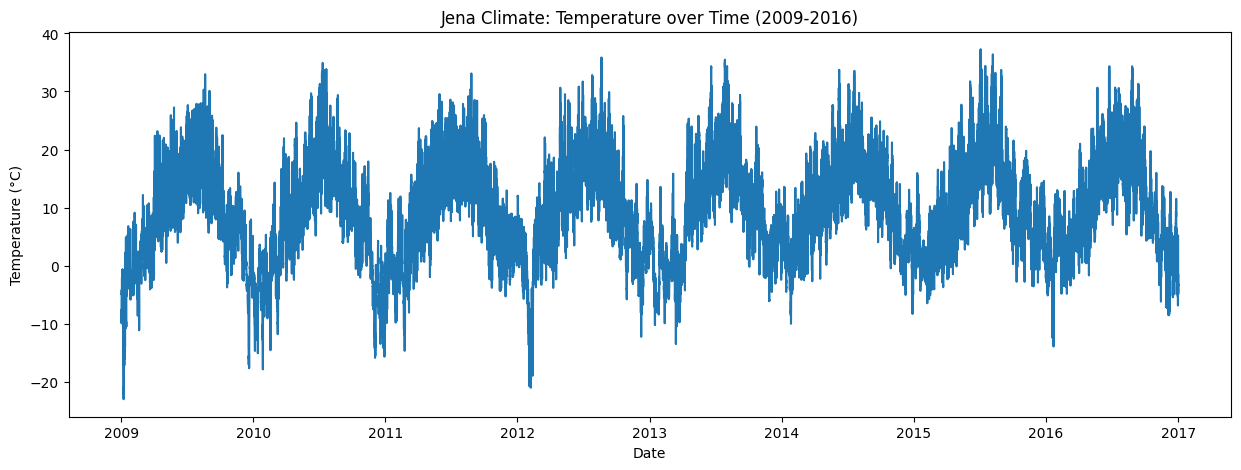

In [7]:
# Plot Temperature over time to visualize seasonality
plt.figure(figsize=(15, 5))
plt.plot(df['T (degC)'])
plt.title('Jena Climate: Temperature over Time (2009-2016)')
plt.ylabel('Temperature (°C)')
plt.xlabel('Date')
plt.show()

In [8]:
# Display summary statistics and check for missing values
display(df.describe())
print('\nMissing values per column:')
display(df.isna().sum())

,p (mbar),T (degC),Tpot (K),Tdew (degC),rh (%),VPmax (mbar),VPact (mbar),VPdef (mbar),sh (g/kg),H2OC (mmol/mol),rho (g/m**3),wv (m/s),max. wv (m/s),wd (deg)
count,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000,420551.000000
mean,989.212776,9.450147,283.492743,4.955854,76.008259,13.576251,9.533756,4.042412,6.022408,9.640223,1216.062748,1.702224,3.056555,174.743738
std,8.358481,8.423365,8.504471,6.730674,16.476175,7.739020,4.184164,4.896851,2.656139,4.235395,39.975208,65.446714,69.016932,86.681693
min,913.600000,-23.010000,250.600000,-25.010000,12.950000,0.950000,0.790000,0.000000,0.500000,0.800000,1059.450000,-9999.000000,-9999.000000,0.000000
25%,984.200000,3.360000,277.430000,0.240000,65.210000,7.780000,6.210000,0.870000,3.920000,6.290000,1187.490000,0.990000,1.760000,124.900000
50%,989.580000,9.420000,283.470000,5.220000,79.300000,11.820000,8.860000,2.190000,5.590000,8.960000,1213.790000,1.760000,2.960000,198.100000
75%,994.720000,15.470000,289.530000,10.070000,89.400000,17.600000,12.350000,5.300000,7.800000,12.490000,1242.770000,2.860000,4.740000,234.100000
max,1015.350000,37.280000,311.340000,23.110000,100.000000,63.770000,28.320000,46.010000,18.130000,28.820000,1393.540000,28.490000,23.500000,360.000000



Missing values per column:


p (mbar)           0
T (degC)           0
Tpot (K)           0
Tdew (degC)        0
rh (%)             0
VPmax (mbar)       0
VPact (mbar)       0
VPdef (mbar)       0
sh (g/kg)          0
H2OC (mmol/mol)    0
rho (g/m**3)       0
wv (m/s)           0
max. wv (m/s)      0
wd (deg)           0
dtype: int64

In [9]:
# Downsample to hourly data (every 6th record)
df_hourly = df.iloc[5::6].copy()

# Define split indices
n = len(df_hourly)
train_end = int(n * 0.7)
val_end = int(n * 0.9)

train_df = df_hourly.iloc[:train_end]
val_df = df_hourly.iloc[train_end:val_end]
test_df = df_hourly.iloc[val_end:]

# 1. Scale Features (X) using StandardScaler
scaler_X = StandardScaler()
train_scaled_X = scaler_X.fit_transform(train_df)
val_scaled_X = scaler_X.transform(val_df)
test_scaled_X = scaler_X.transform(test_df)

# 2. Extract RAW Targets (y) in Celsius
train_targets_y = train_df[['T (degC)']].values
val_targets_y = val_df[['T (degC)']].values
test_targets_y = test_df[['T (degC)']].values

def create_dataset(data_x, data_y, window_size, delay=24, batch_size=256):
    """Creates aligned X and y datasets with correct offset."""
    offset = window_size + delay - 1 
    
    inputs = data_x[:-offset]
    targets = data_y[offset:]
    
    return tf.keras.utils.timeseries_dataset_from_array(
        data=inputs,
        targets=targets,
        sequence_length=window_size,
        batch_size=batch_size,
        shuffle=False
    )

In [10]:
# Define configurations for experiments
time_windows = [24, 72, 168] # 1 day, 3 days, 7 days
architectures = ['SimpleRNN', 'LSTM', 'GRU']

features = train_scaled_X.shape[1] 

# Dictionary to store results
results_dict = {}

In [11]:
def build_model(arch_type, window_size, num_features):
    model = Sequential()
    model.add(Input(shape=(window_size, num_features)))
    
    if arch_type == 'SimpleRNN':
        model.add(SimpleRNN(32, activation='tanh', unroll=True))
    elif arch_type == 'LSTM':
        model.add(LSTM(32, activation='tanh', unroll=True))
    elif arch_type == 'GRU':
        model.add(GRU(32, activation='tanh', unroll=True))

    model.add(Dense(1)) # Pure regression output (no relu)
    
    optimizer = Adam(clipnorm=1.0)
    model.compile(optimizer=optimizer, loss='mse', metrics=[rmsle_shifted])
    return model

In [12]:
EPOCHS = 20
BATCH_SIZE = 256

for window in time_windows:
    train_ds = create_dataset(train_scaled_X, train_targets_y, window_size=window, batch_size=BATCH_SIZE)
    val_ds = create_dataset(val_scaled_X, val_targets_y, window_size=window, batch_size=BATCH_SIZE)
    test_ds = create_dataset(test_scaled_X, test_targets_y, window_size=window, batch_size=BATCH_SIZE)
    
    for arch in architectures:
        print(f"\n--- Training {arch} with {window}h window ---")
        model = build_model(arch, window, num_features=train_scaled_X.shape[1])        
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=3, 
            restore_best_weights=True
        )
        
        history = model.fit(
            train_ds,
            validation_data=val_ds,
            epochs=EPOCHS,
            callbacks=[early_stopping],
            verbose=1
        )
        
        test_loss, test_rmsle = model.evaluate(test_ds, verbose=0)
        print(f"Test RMSLE: {test_rmsle:.4f}")
        
        # Save results
        key = f"{arch}_{window}h"
        results_dict[key] = {
            'history': history.history,
            'test_rmsle': test_rmsle,
            'model': model,
            'test_ds': test_ds
        }


--- Training SimpleRNN with 24h window ---
Epoch 1/20
192/192 [==============================] - 7s 24ms/step - loss: 107.5498 - rmsle_shifted: 0.0329 - val_loss: 59.0463 - val_rmsle_shifted: 0.0241
Epoch 2/20
192/192 [==============================] - 4s 19ms/step - loss: 61.4177 - rmsle_shifted: 0.0263 - val_loss: 61.5830 - val_rmsle_shifted: 0.0264
Epoch 3/20
192/192 [==============================] - 5s 26ms/step - loss: 54.1105 - rmsle_shifted: 0.0247 - val_loss: 47.6418 - val_rmsle_shifted: 0.0226
Epoch 4/20
192/192 [==============================] - 3s 18ms/step - loss: 43.2773 - rmsle_shifted: 0.0219 - val_loss: 35.8141 - val_rmsle_shifted: 0.0193
Epoch 5/20
192/192 [==============================] - 3s 18ms/step - loss: 35.1761 - rmsle_shifted: 0.0197 - val_loss: 27.7851 - val_rmsle_shifted: 0.0167
Epoch 6/20
192/192 [==============================] - 4s 18ms/step - loss: 28.5469 - rmsle_shifted: 0.0176 - val_loss: 23.3086 - val_rmsle_shifted: 0.0153
Epoch 7/20
192/192 [=====

In [13]:
# 1. Compare RMSLE Results into a dataframe
summary_data = []
for key, data in results_dict.items():
    arch, window = key.split('_')
    summary_data.append({
        'Architecture': arch,
        'Window Size': window,
        'Test RMSLE': round(data['test_rmsle'], 4)
    })

summary_df = pd.DataFrame(summary_data).sort_values(by='Test RMSLE').reset_index(drop=True)

print("\n=== OVERALL MODEL PERFORMANCE ===")
display(summary_df)

# 2. Identify Best Model
best_model_key = min(results_dict, key=lambda k: results_dict[k]['test_rmsle'])
best_model = results_dict[best_model_key]['model']
best_test_ds = results_dict[best_model_key]['test_ds']

print(f"\nExtracting cases using best model: {best_model_key}")

# 3. Save the Best Model
os.makedirs('saved_models', exist_ok=True)
best_model_path = f'saved_models/best_rnn_{best_model_key}.keras'
best_model.save(best_model_path)
print(f"Model saved successfully to '{best_model_path}'")


=== OVERALL MODEL PERFORMANCE ===


,Architecture,Window Size,Test RMSLE
0,GRU,72h,0.0105
1,LSTM,72h,0.0106
2,GRU,168h,0.0107
3,GRU,24h,0.0109
4,LSTM,24h,0.0113
5,SimpleRNN,72h,0.0113
6,SimpleRNN,24h,0.0114
7,SimpleRNN,168h,0.0116
8,LSTM,168h,0.0116



Extracting cases using best model: GRU_72h
Model saved successfully to 'saved_models/best_rnn_GRU_72h.keras'


Extracting predictions for all models... (This may take a moment)


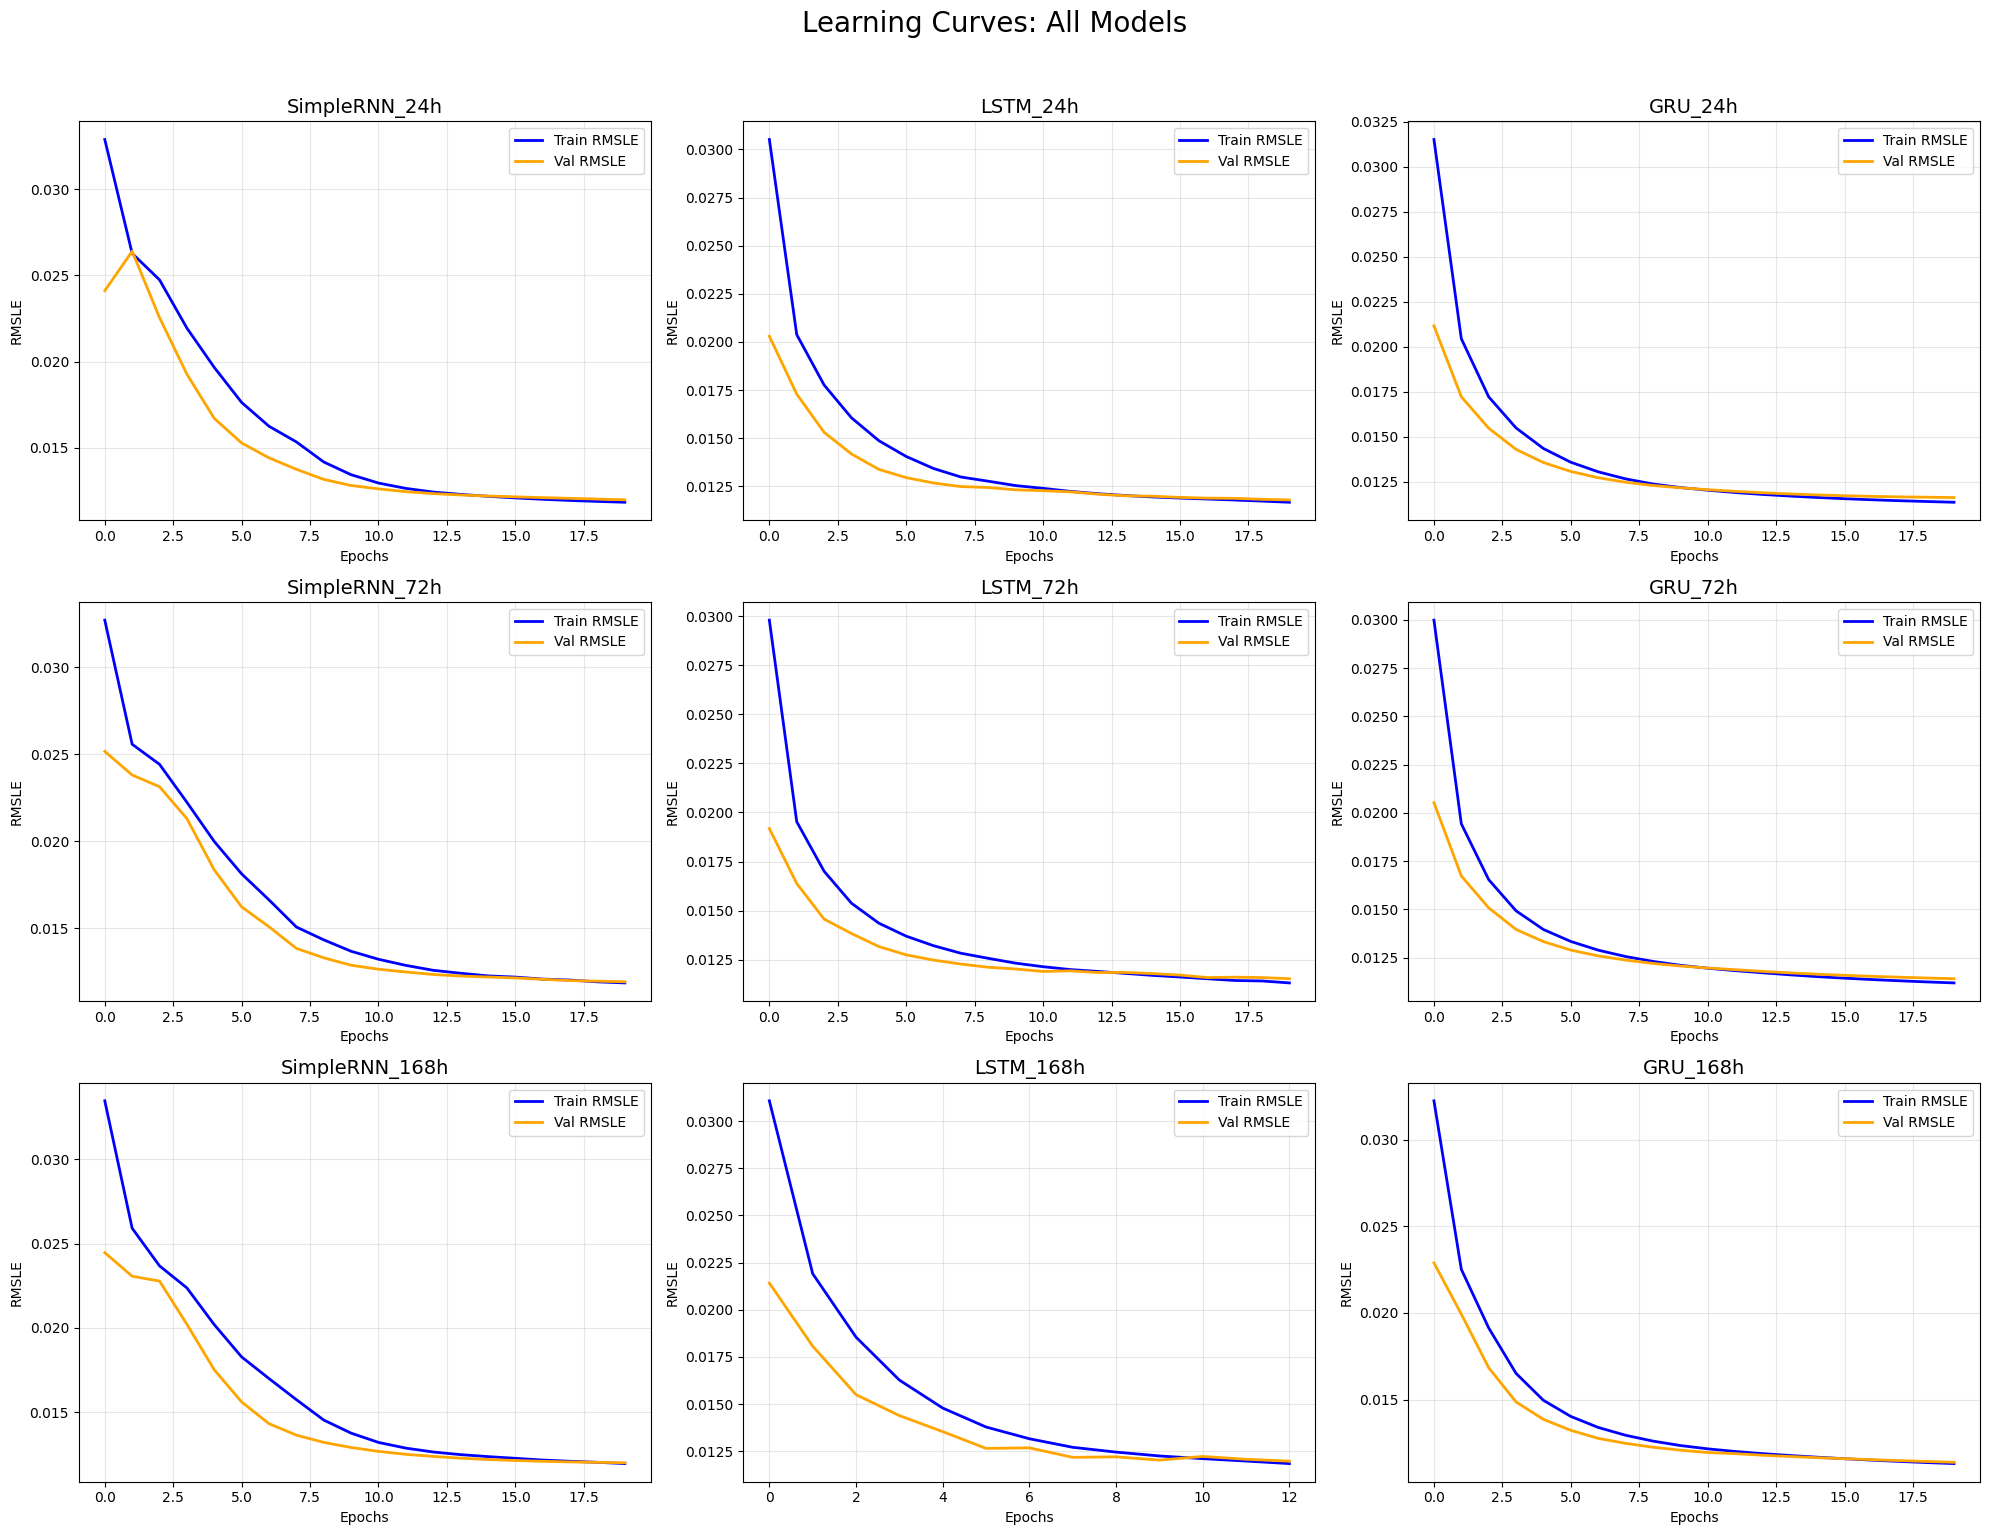

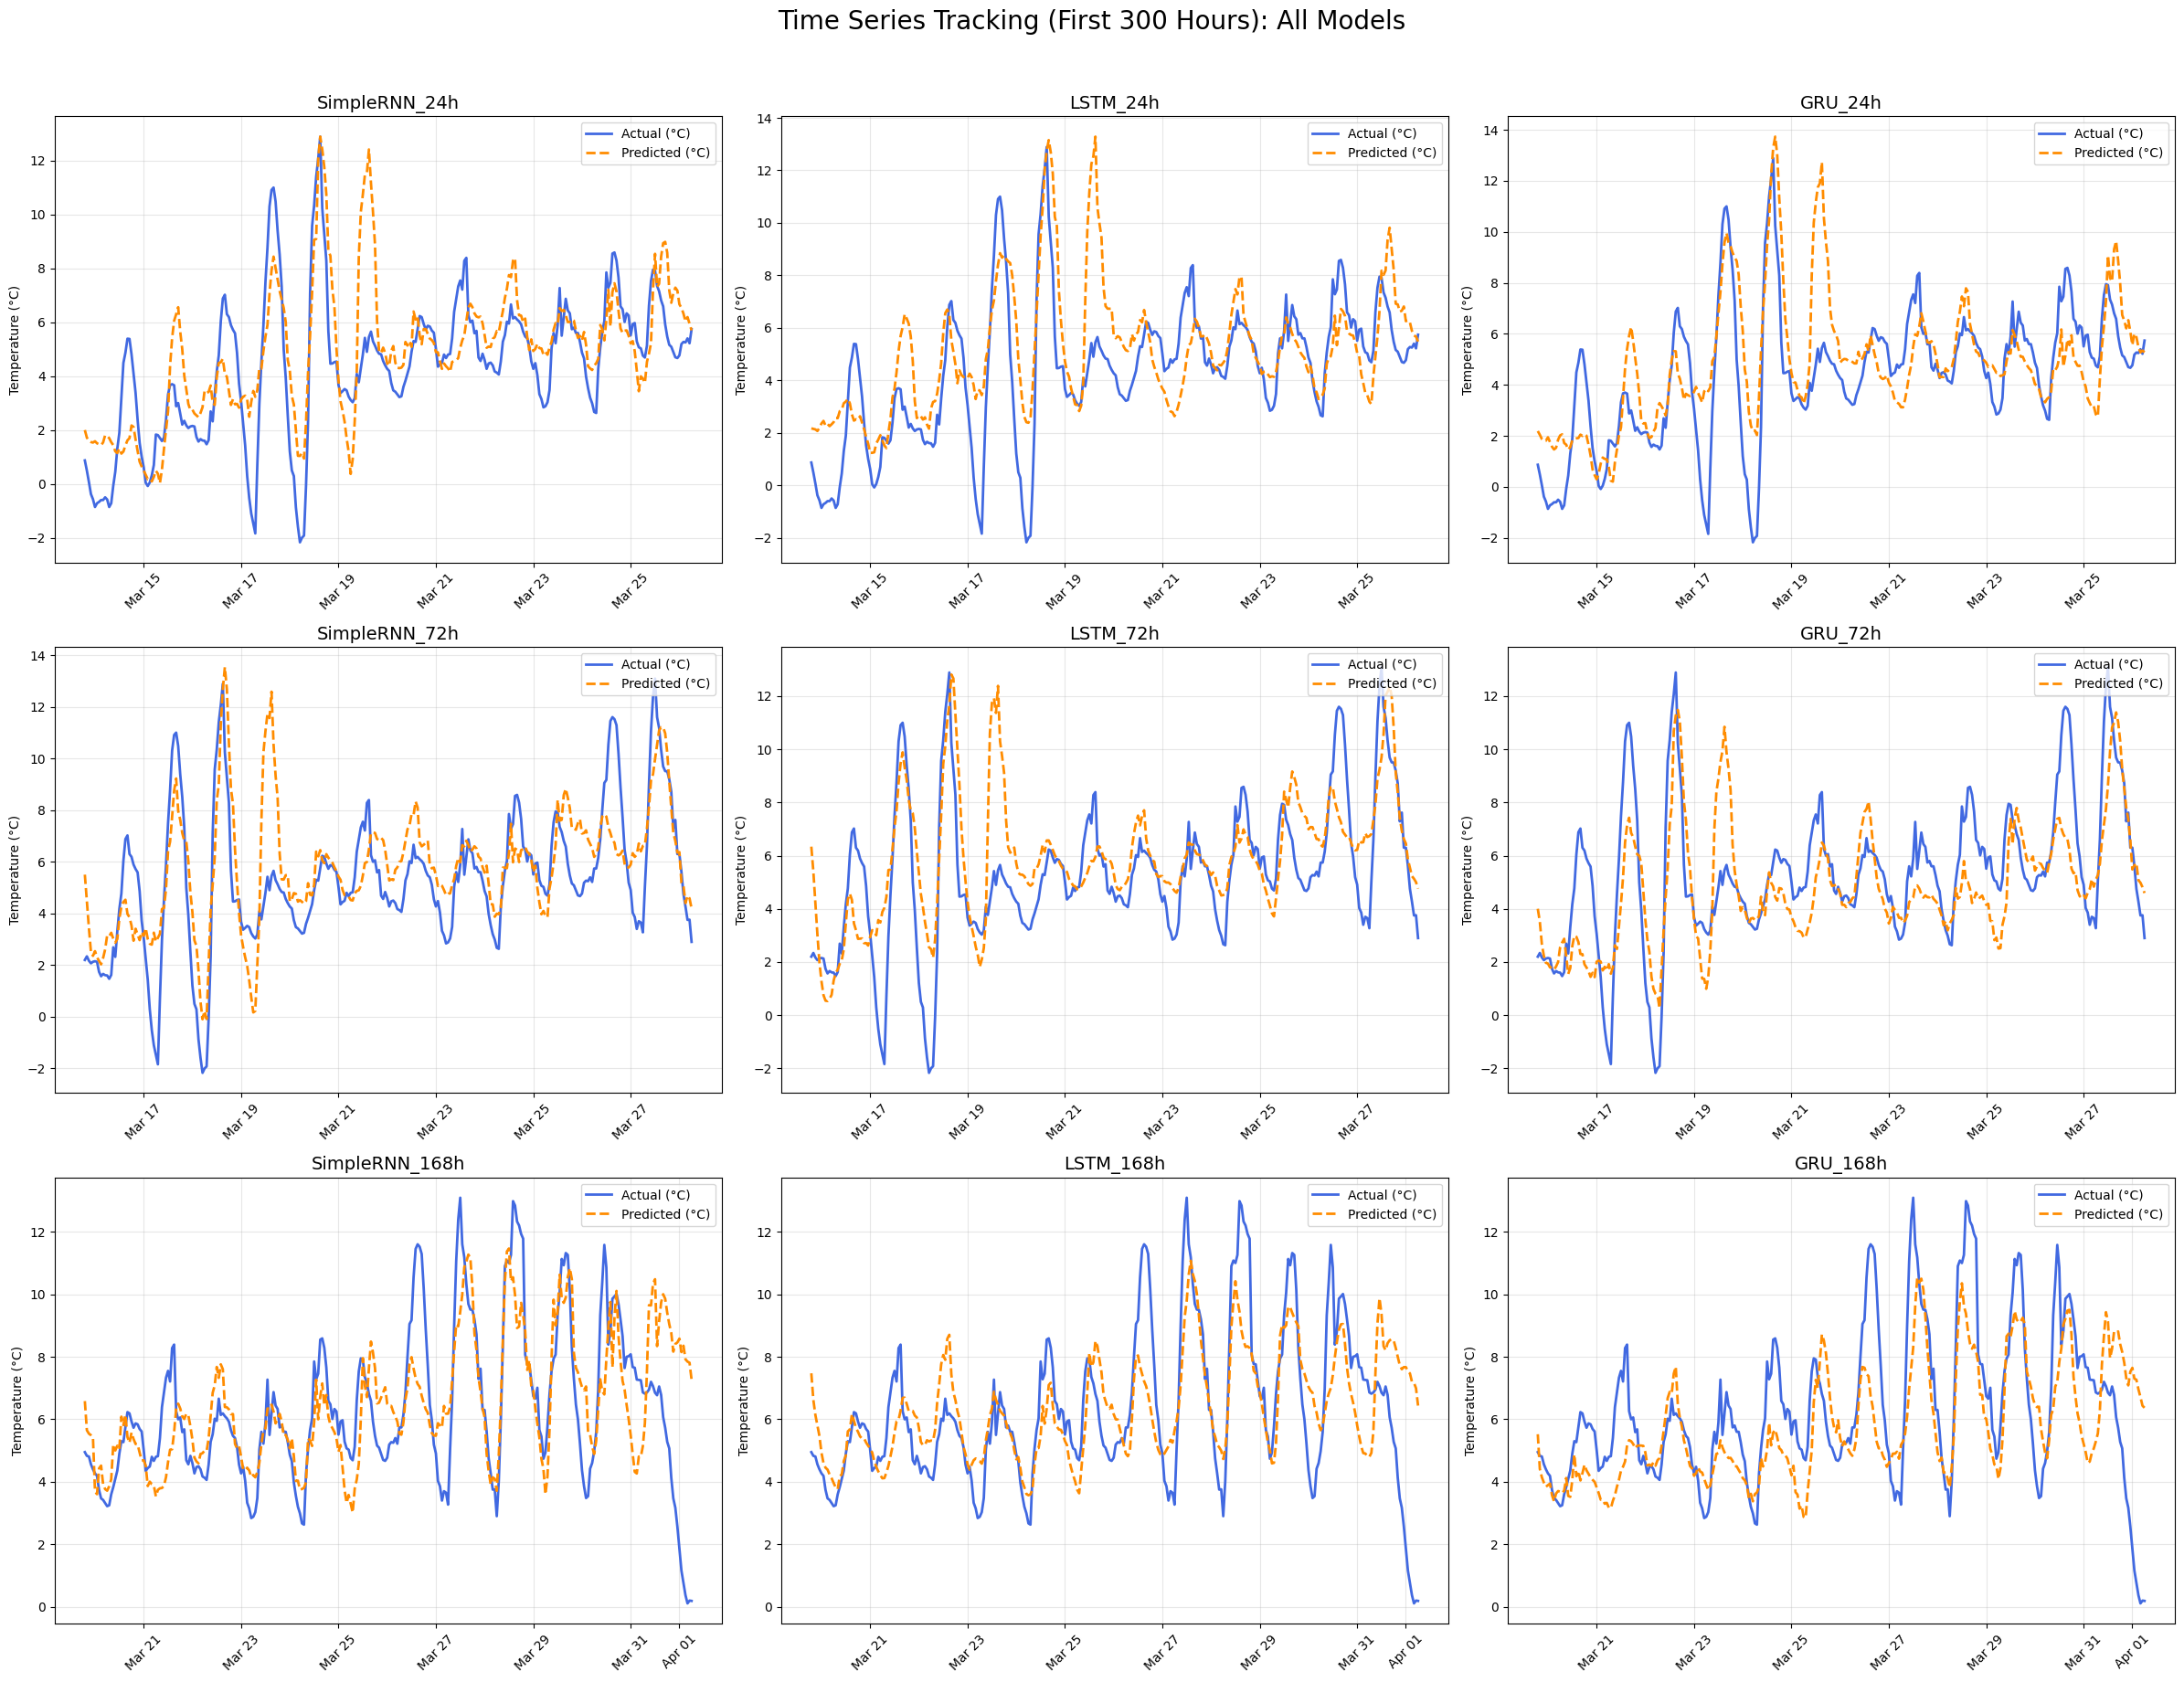

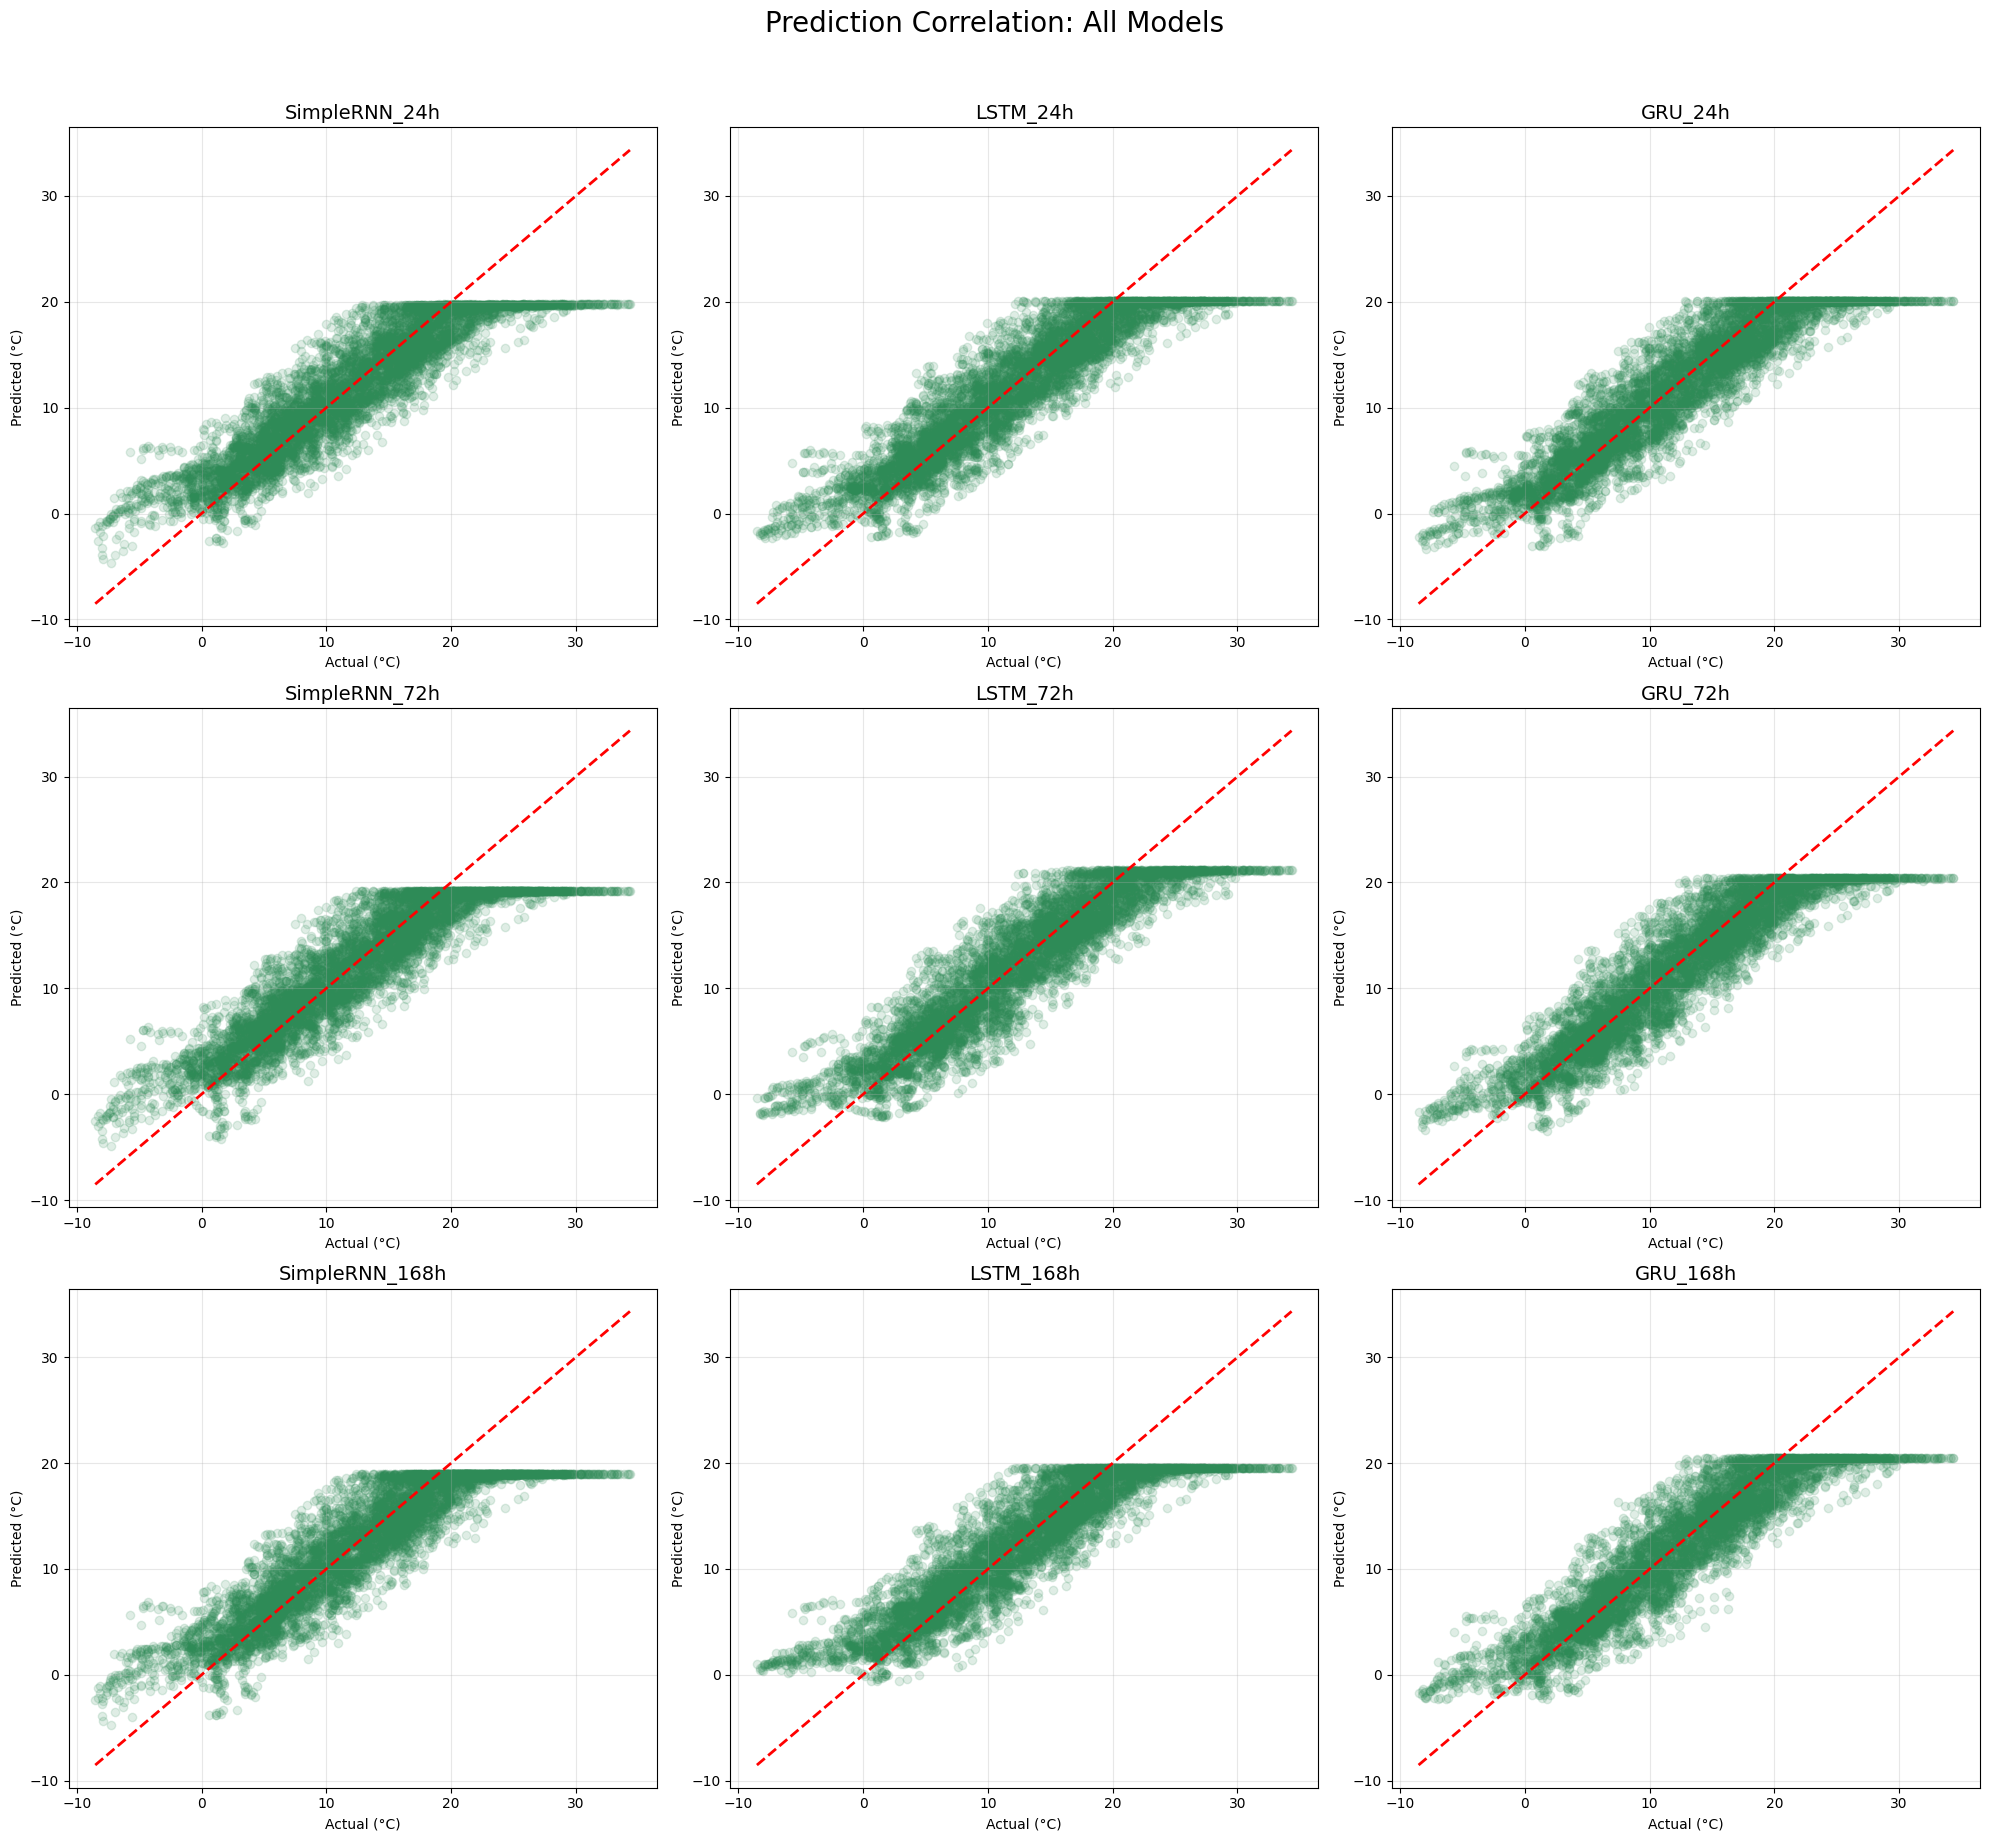

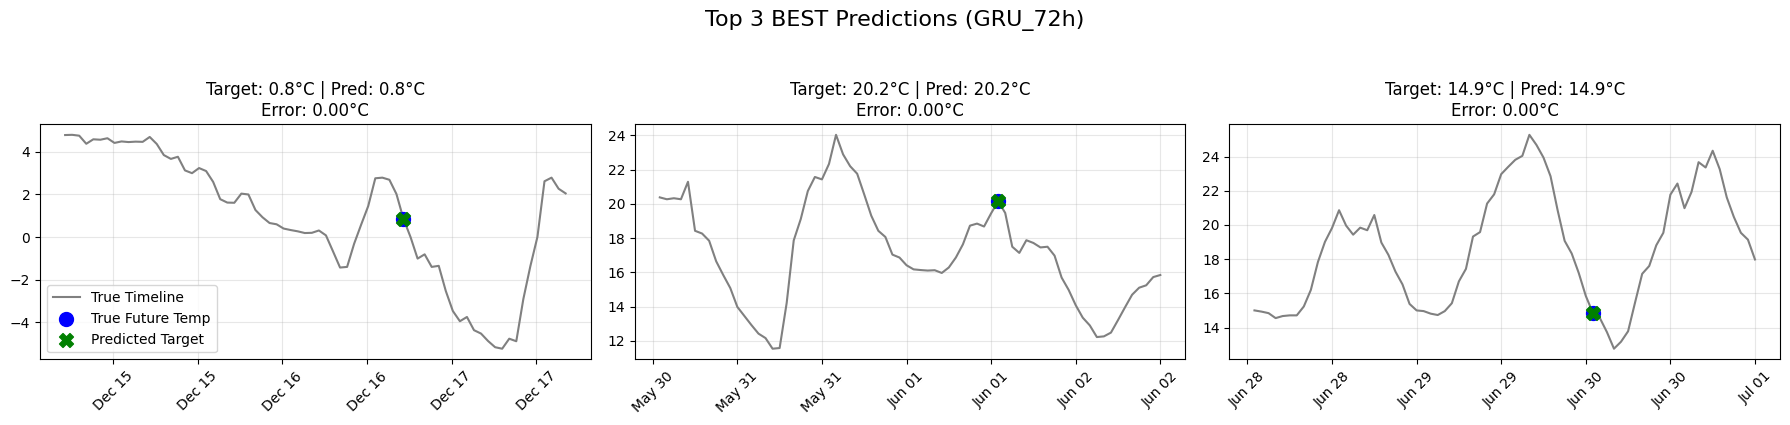

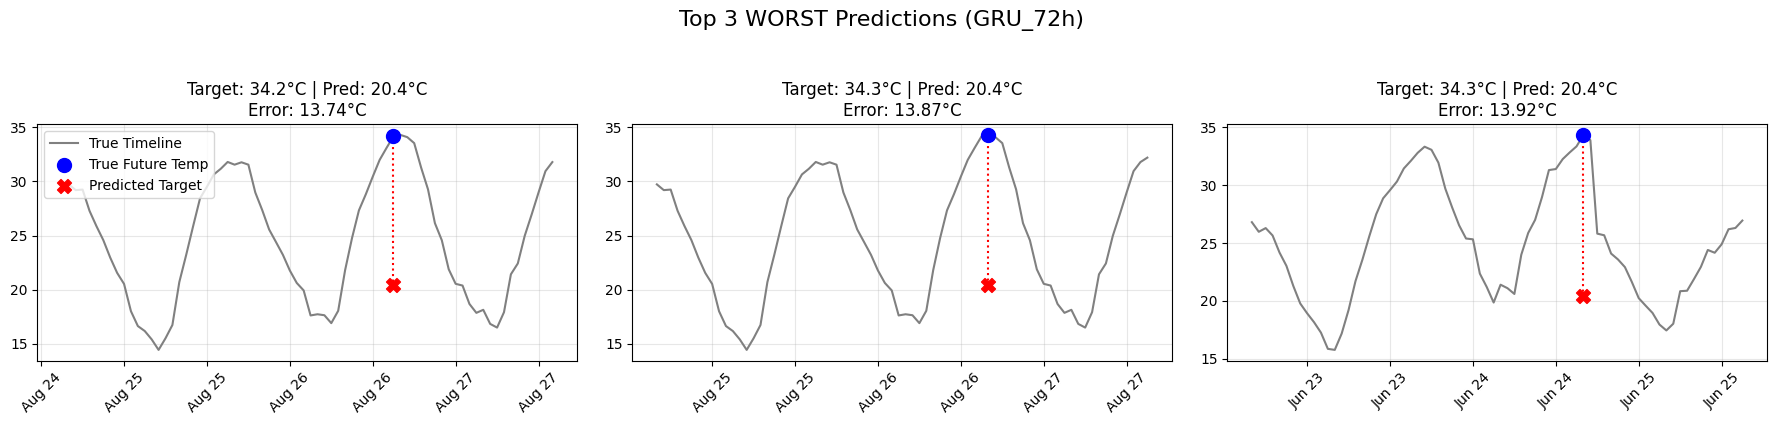

In [16]:
import matplotlib.dates as mdates

# =========================================================
# 9.1 EXTRACT PREDICTIONS AND DATES FOR ALL MODELS
# =========================================================
print("Extracting predictions for all models... (This may take a moment)")
all_model_data = {}

for key, data in results_dict.items():
    model = data['model']
    test_ds = data['test_ds']
    
    y_true_temp, y_pred_temp = [], []
    for x_batch, y_batch in test_ds:
        preds = model.predict(x_batch, verbose=0)
        y_true_temp.extend(y_batch.numpy().flatten())
        y_pred_temp.extend(preds.flatten())
        
    # Dynamically calculate the dates for this specific window size
    window_size = int(key.split('_')[1].replace('h', ''))
    delay = 24
    offset = window_size + delay - 1 
    model_dates = test_df.index[offset:]
    
    all_model_data[key] = {
        'true': np.array(y_true_temp),
        'pred': np.array(y_pred_temp),
        'dates': model_dates
    }

# =========================================================
# 9.2 TRAINING CURVES FOR ALL MODELS (3x3 Grid)
# =========================================================
num_models = len(results_dict)
cols = 3
rows = math.ceil(num_models / cols)

fig, axes = plt.subplots(rows, cols, figsize=(20, 5 * rows))
fig.suptitle('Learning Curves: All Models', fontsize=20, y=1.02)
axes = axes.flatten()

for i, (key, data) in enumerate(results_dict.items()):
    history = data['history']
    train_metric = [k for k in history.keys() if 'rmsle' in k and 'val' not in k][0]
    val_metric = [k for k in history.keys() if 'val_rmsle' in k][0]
    
    axes[i].plot(history[train_metric], label='Train RMSLE', color='blue', linewidth=2)
    axes[i].plot(history[val_metric], label='Val RMSLE', color='orange', linewidth=2)
    axes[i].set_title(f'{key}', fontsize=14)
    axes[i].set_xlabel('Epochs')
    axes[i].set_ylabel('RMSLE')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# 9.3 PREDICTED VS ACTUAL FOR ALL MODELS (3x3 Grid)
# =========================================================
fig, axes = plt.subplots(rows, cols, figsize=(24, 6 * rows))
fig.suptitle('Time Series Tracking (First 300 Hours): All Models', fontsize=20, y=1.02)
axes = axes.flatten()

for i, (key, m_data) in enumerate(all_model_data.items()):
    dates = m_data['dates'][:300]
    t_true = m_data['true'][:300]
    t_pred = m_data['pred'][:300]
    
    axes[i].plot(dates, t_true, label='Actual (°C)', color='royalblue', linewidth=2)
    axes[i].plot(dates, t_pred, label='Predicted (°C)', color='darkorange', linestyle='--', linewidth=2)
    axes[i].set_title(f'{key}', fontsize=14)
    axes[i].set_ylabel('Temperature (°C)')
    axes[i].legend(loc='upper right')
    axes[i].grid(True, alpha=0.3)
    axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    
    for tick in axes[i].get_xticklabels():
        tick.set_rotation(45)

plt.tight_layout()
plt.show()

# =========================================================
# 9.4 SCATTER CORRELATION FOR ALL MODELS (3x3 Grid)
# =========================================================
fig, axes = plt.subplots(rows, cols, figsize=(20, 6 * rows))
fig.suptitle('Prediction Correlation: All Models', fontsize=20, y=1.02)
axes = axes.flatten()

for i, (key, m_data) in enumerate(all_model_data.items()):
    t_true = m_data['true']
    t_pred = m_data['pred']
    
    axes[i].scatter(t_true, t_pred, alpha=0.15, color='seagreen')
    
    min_val = min(min(t_true), min(t_pred))
    max_val = max(max(t_true), max(t_pred))
    axes[i].plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2)
    
    axes[i].set_title(f'{key}', fontsize=14)
    axes[i].set_xlabel('Actual (°C)')
    axes[i].set_ylabel('Predicted (°C)')
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =========================================================
# 9.5 BEST-CASE / WORST-CASE WINDOWS (BEST MODEL ONLY)
# =========================================================
# We keep this strictly for the best model to avoid cluttering the notebook with 27 subplots
best_data = all_model_data[best_model_key]
true_celsius = best_data['true']
pred_celsius = best_data['pred']
test_dates = best_data['dates']

errors_celsius = np.abs(true_celsius - pred_celsius)
error_indices = np.argsort(errors_celsius)

best_idx = error_indices[:3]
worst_idx = error_indices[-3:]

def plot_context_windows(indices, title, color_pred):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"{title} ({best_model_key})", fontsize=16, y=1.05)
    
    for i, idx in enumerate(indices):
        start_plot = max(0, idx - 48)
        end_plot = min(len(true_celsius), idx + 24)
        
        window_dates = test_dates[start_plot:end_plot]
        target_date = test_dates[idx]
        
        axes[i].plot(window_dates, true_celsius[start_plot:end_plot], color='gray', label='True Timeline')
        axes[i].scatter([target_date], [true_celsius[idx]], color='blue', s=100, zorder=5, label='True Future Temp')
        axes[i].scatter([target_date], [pred_celsius[idx]], color=color_pred, s=100, marker='X', zorder=5, label='Predicted Target')
        axes[i].plot([target_date, target_date], [true_celsius[idx], pred_celsius[idx]], color='red', linestyle=':')
        
        err_val = errors_celsius[idx]
        axes[i].set_title(f"Target: {true_celsius[idx]:.1f}°C | Pred: {pred_celsius[idx]:.1f}°C\nError: {err_val:.2f}°C")
        axes[i].grid(True, alpha=0.3)
        axes[i].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
        
        for tick in axes[i].get_xticklabels():
            tick.set_rotation(45)
            
        if i == 0: axes[i].legend()

    plt.tight_layout()
    plt.show()

plot_context_windows(best_idx, "Top 3 BEST Predictions", color_pred='green')
plot_context_windows(worst_idx, "Top 3 WORST Predictions", color_pred='red')